tensor([[1., 0., 0., 1.],
        [1., 1., 1., 0.],
        [1., 1., 1., 0.],
        [0., 1., 0., 1.],
        [0., 0., 0., 1.]])


<Figure size 1000x700 with 0 Axes>

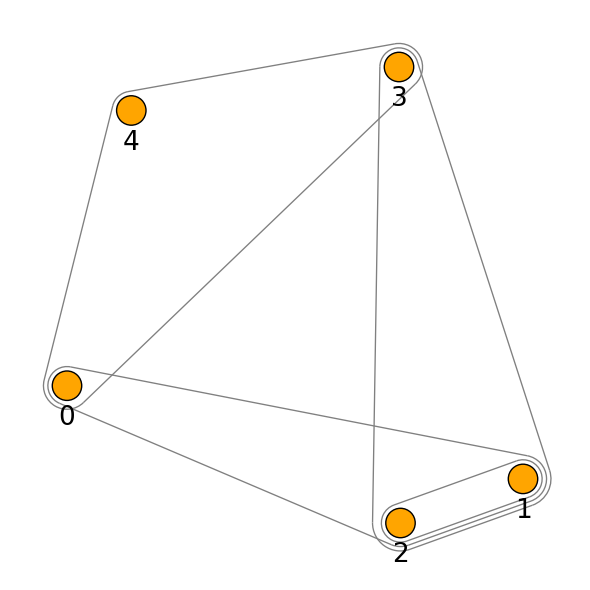

In [3]:
# 定义一个超图
import dhg
from dhg.visualization import draw_hypergraph
import matplotlib.pyplot as plt
hg = dhg.Hypergraph(5, [(0, 1, 2), (1, 3, 2), (1, 2), (0, 3, 4)]) # type: ignore
print(hg.H.to_dense())
# 核心代码：使用 v_label 参数
plt.figure(figsize=(10, 7)) # 放大画布以便观察
draw_hypergraph(
    hg, 
    v_label=[str(i) for i in range(5)], # 关键点：给每个节点分配 0-4 的字符串标签# 调大节点尺寸，防止标签遮挡
    v_color="orange",                   # 鲜艳的节点颜色# 调整标签文字大小
)
plt.show()

你的理解完全正确！你整理的这个表格，就是该超图的**关联矩阵（Incidence Matrix）$H$** 的完整表达。

为了让你在 GitHub 上保存的文档更具专业性，我为你将这个分析整理成了标准的 Markdown 格式。

---

### 📊 超图关联矩阵 (Incidence Matrix) 解析

关联矩阵 $H$ 定义了节点与超边之间的从属关系。对于节点 $v_i$ 和超边 $e_j$，如果 $v_i \in e_j$，则 $H_{ij} = 1$，否则为 $0$。

#### 关联矩阵表格

| 节点 \ 超边 | $e_0 (0,1,2)$ | $e_1 (1,2,3)$ | $e_2 (1,2)$ | $e_3 (0,3,4)$ |
| --- | --- | --- | --- | --- |
| **0** | 1 | 0 | 0 | 1 |
| **1** | 1 | 1 | 1 | 0 |
| **2** | 1 | 1 | 1 | 0 |
| **3** | 0 | 1 | 0 | 1 |
| **4** | 0 | 0 | 0 | 1 |

---

#### 核心逻辑洞察

1. **行向量 (Row Vectors)**：每一行表示该节点参与了哪些超边。
* 例如，节点 1 参与了 $e_0, e_1, e_2$，因此其行向量为 `[1, 1, 1, 0]`。


2. **列向量 (Column Vectors)**：每一列表示该超边包含了哪些节点。
* 例如，超边 3 包含了节点 0, 3, 4，因此其列向量为 `[1, 0, 0, 1, 1]^T`。


3. **稀疏性 (Sparsity)**：在大规模图中，$H$ 矩阵通常是非常稀疏的，这也是为什么在代码中我们使用 `hg.H.to_dense()` 将稀疏存储的张量转换为矩阵视图进行观察。

---

### 💡 为什么这很重要？

在 HGNN (Hypergraph Neural Network) 中，信息传递的本质就是利用这个 $H$ 矩阵实现节点与超边之间的特征互换：

* **节点到超边**：利用 $H^T$ 将节点特征聚合到超边上。
* **超边到节点**：利用 $H$ 将聚合后的超边信息传播回节点。

你可以把这份 Markdown 存入你的项目 `docs/incidence_matrix_analysis.md` 中，作为你未来模型调试时的数学参照表。



In [ ]:
# 星扩展
# 1. 创建一个简单的超图
# 5个节点，2条超边：e0=[0, 1, 2], e1=[2, 3, 4]
hg = dhg.Hypergraph(5, [(0, 1, 2), (2, 3, 4)]) # type: ignore

# 2. 进行星形扩展
g_star, v_mask = dhg.Graph.from_hypergraph_star(hg) # type: ignore

print(f"原始节点数: {hg.num_v}")
print(f"扩展后的总节点数: {g_star.num_v}") # 应为 5 + 2 = 7
print(f"顶点掩码 (v_mask): {v_mask}")

原始节点数: 5
扩展后的总节点数: 7
顶点掩码 (v_mask): tensor([ True,  True,  True,  True,  True, False, False])
